<a href="https://colab.research.google.com/github/Harshal-Bsys27/MachineLearning_prac/blob/main/DAV_EXP_1_DATAPREP_DATACLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**implement data prep and cleaning**

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load dataset
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target column
df['species'] = iris.target

# Display first rows
print(df.head())

# Info
print(df.info())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes:

In [ ]:
# Check missing values
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [ ]:
# (Dataset has no missing values, so we simulate one for demonstration)
df.iloc[0, 0] = np.nan

# Fill missing value using mean
df.fillna(df.mean(), inplace=True)

In [ ]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [ ]:
# Convert column to numeric (already numeric, just demonstration)
df['sepal length (cm)'] = pd.to_numeric(df['sepal length (cm)'], errors='coerce')

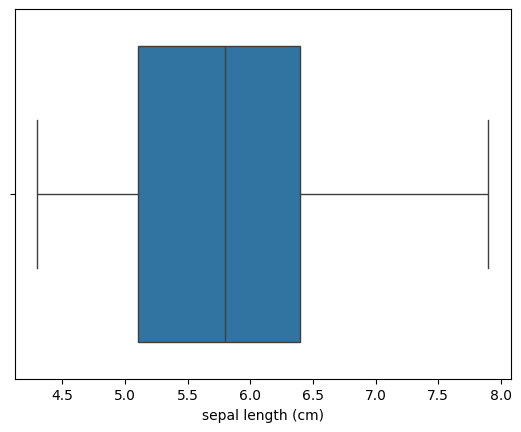

In [ ]:
# Boxplot for outlier detection
sns.boxplot(x=df['sepal length (cm)'])
plt.show()

In [ ]:
# Convert numeric species to labels
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

# Encode back to numeric
df['species'] = df['species'].map({
    'setosa': 0,
    'versicolor': 1,
    'virginica': 2
})

In [ ]:
# Apply Standard Scaling
scaler = StandardScaler()
df.iloc[:, :-1] = scaler.fit_transform(df.iloc[:, :-1])

In [ ]:
# Final checks
print(df.isnull().sum())
print(df.dtypes)
print(df.shape)

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
dtype: object
(149, 5)


In [ ]:
# Save cleaned dataset
df.to_csv("cleaned_iris.csv", index=False)